In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score
import pennylane as qml
from mamba_ssm import Mamba

# ===============================
# DATASET + DATALOADERS
# ===============================

class UAVHSICropDataset(Dataset):
    def __init__(self, root_dir: str, split: str = "Training"):
        if split in ["Training", "Validation"]:
            base = os.path.join(root_dir, split)
        elif split == "Test":
            base = root_dir
        else:
            raise ValueError("split must be Training, Validation or Test")
        
        self.rs_dir = os.path.join(base, "rs")
        self.gt_dir = os.path.join(base, "gt")
        self.rs_files = sorted(glob.glob(os.path.join(self.rs_dir, "*.npy")))
        self.gt_files = sorted(glob.glob(os.path.join(self.gt_dir, "*.npy")))
        assert len(self.rs_files) == len(self.gt_files), "rs/gt count mismatch"

    def __len__(self):
        return len(self.rs_files)

    def normalize_per_band(self, rs):
        mean = rs.mean(axis=(0,1), keepdims=True)
        std  = rs.std(axis=(0,1), keepdims=True)
        std[std < 1e-6] = 1e-6
        return (rs - mean) / std

    def __getitem__(self, idx: int):
        rs = np.load(self.rs_files[idx]).astype(np.float32)
        gt = np.load(self.gt_files[idx]).astype(np.int64)
        rs = self.normalize_per_band(rs)
        rs = torch.from_numpy(rs).permute(2,0,1).float()
        gt = torch.from_numpy(gt).long()
        return rs, gt

def make_loaders(root_train, root_test, batch_size=8, num_workers=2):
    train_ds = UAVHSICropDataset(root_train, "Training")
    val_ds = UAVHSICropDataset(root_train, "Validation")
    test_ds = UAVHSICropDataset(root_test, "Test")
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader

# ===============================
# CNN + ATTENTION MODULES
# ===============================

class SpectralSE(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, max(channels//reduction, 8), 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(channels//reduction, 8), channels, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x)

class MultiScaleCNN(nn.Module):
    def __init__(self, in_channels=200, d_model=64):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, d_model, 3, padding=1, bias=False),
            nn.BatchNorm2d(d_model), nn.ReLU(inplace=True)
        )
        self.dec = nn.Sequential(
            nn.Conv2d(32 + d_model, d_model, 3, padding=1, bias=False),
            nn.BatchNorm2d(d_model), nn.ReLU(inplace=True)
        )
        self.se = SpectralSE(d_model)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e2_up = F.interpolate(e2, size=e1.shape[-2:], mode='bilinear', align_corners=False)
        feat = self.dec(torch.cat([e1, e2_up], dim=1))
        return self.se(feat)

# ===============================
# QUANTUM HEAD (PERMANENT CPU PINNED)
# ===============================

class QuantumGlobalHead(nn.Module):
    def __init__(self, embed_dim=64, num_classes=30, n_qubits=4, n_layers=2):
        super().__init__()
        self.n_qubits = n_qubits
        self.reduce_cpu = nn.Linear(embed_dim, n_qubits)
        self.fc_cpu = nn.Linear(n_qubits, num_classes)
        
        dev = qml.device("default.qubit", wires=n_qubits)
        @qml.qnode(dev, interface="torch")
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits))
            qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
        
        self.qlayer = qml.qnn.TorchLayer(
            circuit, weight_shapes={"weights": (n_layers, n_qubits)}
        )
        self.to(torch.device('cpu'))

    def to(self, *args, **kwargs):
        return super().to(torch.device('cpu'))

    def cuda(self, device=None):
        return self

    def _apply(self, fn):
        super()._apply(fn)
        self.reduce_cpu.to('cpu')
        self.fc_cpu.to('cpu')
        self.qlayer.to('cpu')
        return self

    def forward(self, x_gpu):
        x_cpu = x_gpu.to('cpu').float()
        x_red = torch.tanh(self.reduce_cpu(x_cpu))
        x_q = self.qlayer(x_red)
        x_out = self.fc_cpu(x_q)
        return x_out.to(x_gpu.device)

# ===============================
# HYBRID LOSS (CE + LOG-COSH DICE)
# ===============================

class HybridCELoss_LogCoshDice(nn.Module):
    def __init__(self, num_classes=30, alpha=0.5, class_weights=None, eps=1e-5):
        super().__init__()
        self.alpha = alpha
        self.num_classes = num_classes
        self.eps = eps
        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None else nn.CrossEntropyLoss()
    
    def forward(self, logits, target):
        # Cross-entropy
        ce = self.ce_loss(logits, target)
        
        # Log-Cosh Dice
        pred = F.softmax(logits, dim=1)
        target_onehot = F.one_hot(target, num_classes=self.num_classes).permute(0, 3, 1, 2).float()
        
        intersect = (pred * target_onehot).sum(dim=(0, 2, 3))
        union = pred.sum(dim=(0, 2, 3)) + target_onehot.sum(dim=(0, 2, 3))
        dice = 1 - (2 * intersect + self.eps) / (union + self.eps)
        log_cosh_dice = torch.log(torch.cosh(dice)).mean()
        
        return (1 - self.alpha) * ce + self.alpha * log_cosh_dice

# ===============================
# MAIN MODEL
# ===============================

class CNN_BiSpectralMamba_Quantum(nn.Module):
    def __init__(self, in_channels=200, num_classes=30, d_model=64, d_state=16, alpha_init=0.0):
        super().__init__()
        self.num_classes = num_classes
        self.cnn = MultiScaleCNN(in_channels, d_model)
        self.mamba_forward = Mamba(d_model=d_model, d_state=d_state, d_conv=4, expand=2)
        self.mamba_backward = Mamba(d_model=d_model, d_state=d_state, d_conv=4, expand=2)
        self.cls_head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, num_classes))
        self.quantum_head = QuantumGlobalHead(d_model, num_classes)
        self.alpha = nn.Parameter(torch.tensor(alpha_init))

    def forward(self, x, output_size):
        B, C, H_in, W_in = x.shape
        feat = self.cnn(x)
        tokens = feat.permute(0, 2, 3, 1).reshape(B, -1, feat.shape[1])
        fwd = self.mamba_forward(tokens)
        bwd = torch.flip(self.mamba_backward(torch.flip(tokens, dims=[1])), dims=[1])
        fused = fwd + bwd
        
        classical = self.cls_head(fused)
        classical_map = classical.view(B, H_in, W_in, self.num_classes).permute(0, 3, 1, 2).contiguous()
        
        global_token = fused.mean(dim=1)
        logits_q = self.quantum_head(global_token)
        logits_q = logits_q.view(B, self.num_classes, 1, 1).expand_as(classical_map)
        
        logits = classical_map + torch.tanh(self.alpha) * logits_q
        return F.interpolate(logits, size=output_size, mode="bilinear", align_corners=False)

# ===============================
# TRAINING / TESTING MAIN
# ===============================

def main():
    root_train = "/home/mkhan186/scratch/uavhsi/Train"
    root_test  = "/home/mkhan186/scratch/uavhsi/Test"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    train_loader, val_loader, test_loader = make_loaders(root_train, root_test, batch_size=8)
    sample_rs, _ = next(iter(train_loader))
    
    model = CNN_BiSpectralMamba_Quantum(in_channels=sample_rs.shape[1]).to(device)
    print(f"Total Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    all_gts = np.concatenate([gt.numpy().ravel() for _, gt in train_loader])
    class_counts = np.bincount(all_gts, minlength=30)
    class_weights = torch.tensor(1.0 / (np.sqrt(class_counts) + 1e-6)**0.7, device=device).float()

    # USING HYBRID CE + LOG-COSH DICE LOSS
    criterion = HybridCELoss_LogCoshDice(num_classes=30, alpha=0.5, class_weights=class_weights)
    optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

    best_val_loss = float("inf")
    for epoch in range(1, 101):
        print(f"\nEpoch {epoch}/100")
        model.train()
        train_loss = 0
        for rs, gt in tqdm(train_loader, desc="Train"):
            rs, gt = rs.to(device), gt.to(device)
            optimizer.zero_grad()
            logits = model(rs, gt.shape[-2:])
            loss = criterion(logits, gt)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        val_correct, val_total, val_loss = 0, 0, 0
        with torch.no_grad():
            for rs, gt in val_loader:
                rs, gt = rs.to(device), gt.to(device)
                logits = model(rs, gt.shape[-2:])
                val_loss += criterion(logits, gt).item()
                val_correct += (logits.argmax(1) == gt).sum().item()
                val_total += gt.numel()
        
        avg_val = val_loss / len(val_loader)
        val_oa = val_correct / val_total
        print(f"Val Loss: {avg_val:.4f} | Val OA: {val_oa*100:.2f}%")
        
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), "best_hybrid_model.pth")
            print("→ Saved Best Weights")

    # FINAL TESTING
    print("\n" + "="*40 + "\nFINAL TEST RESULTS\n" + "="*40)
    model.load_state_dict(torch.load("best_hybrid_model.pth", map_location=device))
    model.eval()
    all_preds, all_gts_test = [], []
    with torch.no_grad():
        for rs, gt in tqdm(test_loader, desc="Testing"):
            rs, gt = rs.to(device), gt.to(device)
            logits = model(rs, gt.shape[-2:])
            all_preds.extend(logits.argmax(1).cpu().numpy().ravel())
            all_gts_test.extend(gt.cpu().numpy().ravel())
    
    test_oa = (np.array(all_preds) == np.array(all_gts_test)).mean()
    test_kappa = cohen_kappa_score(all_gts_test, all_preds)
    print(f"TEST OA: {test_oa*100:.2f}%")
    print(f"TEST KAPPA: {test_kappa:.4f}")

if __name__ == "__main__":
    main()

/home/mkhan186/hsi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total Trainable Parameters: 246,793

Epoch 1/100


Train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:04<00:00,  8.14it/s]


Val Loss: 1.4510 | Val OA: 53.43%
→ Saved Best Weights

Epoch 2/100


Train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:02<00:00, 17.42it/s]


...

Val Loss: 0.7142 | Val OA: 82.40%

Epoch 100/100


Train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:02<00:00, 14.40it/s]
/tmp/ipykernel_349231/3619030919.py:268: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the l

Val Loss: 0.6861 | Val OA: 81.17%

FINAL TEST RESULTS


Testing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:02<00:00,  4.43it/s]


TEST OA: 82.93%
TEST KAPPA: 0.7994


In [1]:
!pip install seaborn

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic


In [5]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score
import pennylane as qml
from mamba_ssm import Mamba
 
# ===============================
# DATASET + DATALOADERS
# ===============================
 
class UAVHSICropDataset(Dataset):
    def __init__(self, root_dir: str, split: str = "Training"):
        if split in ["Training", "Validation"]:
            base = os.path.join(root_dir, split)
        elif split == "Test":
            base = root_dir
        else:
            raise ValueError("split must be Training, Validation or Test")
        
        self.rs_dir = os.path.join(base, "rs")
        self.gt_dir = os.path.join(base, "gt")
        self.rs_files = sorted(glob.glob(os.path.join(self.rs_dir, "*.npy")))
        self.gt_files = sorted(glob.glob(os.path.join(self.gt_dir, "*.npy")))
        assert len(self.rs_files) == len(self.gt_files), "rs/gt count mismatch"
 
    def __len__(self):
        return len(self.rs_files)
 
    def normalize_per_band(self, rs):
        mean = rs.mean(axis=(0,1), keepdims=True)
        std  = rs.std(axis=(0,1), keepdims=True)
        std[std < 1e-6] = 1e-6
        return (rs - mean) / std
 
    def __getitem__(self, idx: int):
        rs = np.load(self.rs_files[idx]).astype(np.float32)
        gt = np.load(self.gt_files[idx]).astype(np.int64)
        rs = self.normalize_per_band(rs)
        rs = torch.from_numpy(rs).permute(2,0,1).float()
        gt = torch.from_numpy(gt).long()
        return rs, gt
 
def make_loaders(root_train, root_test, batch_size=8, num_workers=2):
    train_ds = UAVHSICropDataset(root_train, "Training")
    val_ds = UAVHSICropDataset(root_train, "Validation")
    test_ds = UAVHSICropDataset(root_test, "Test")
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader
 
# ===============================
# CNN + ATTENTION MODULES
# ===============================
 
class SpectralSE(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, max(channels//reduction, 8), 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(channels//reduction, 8), channels, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x)
 
class MultiScaleCNN(nn.Module):
    def __init__(self, in_channels=200, d_model=64):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, d_model, 3, padding=1, bias=False),
            nn.BatchNorm2d(d_model), nn.ReLU(inplace=True)
        )
        self.dec = nn.Sequential(
            nn.Conv2d(32 + d_model, d_model, 3, padding=1, bias=False),
            nn.BatchNorm2d(d_model), nn.ReLU(inplace=True)
        )
        self.se = SpectralSE(d_model)
 
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e2_up = F.interpolate(e2, size=e1.shape[-2:], mode='bilinear', align_corners=False)
        feat = self.dec(torch.cat([e1, e2_up], dim=1))
        return self.se(feat)
 
# ===============================
# QUANTUM HEAD (PERMANENT CPU PINNED)
# ===============================
 
class QuantumGlobalHead(nn.Module):
    def __init__(self, embed_dim=64, num_classes=30, n_qubits=4, n_layers=2):
        super().__init__()
        self.n_qubits = n_qubits
        self.reduce_cpu = nn.Linear(embed_dim, n_qubits)
        self.fc_cpu = nn.Linear(n_qubits, num_classes)
        
        dev = qml.device("default.qubit", wires=n_qubits)
        @qml.qnode(dev, interface="torch")
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits))
            qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
        
        self.qlayer = qml.qnn.TorchLayer(
            circuit, weight_shapes={"weights": (n_layers, n_qubits)}
        )
        self.to(torch.device('cpu'))
 
    def to(self, *args, **kwargs):
        return super().to(torch.device('cpu'))
 
    def cuda(self, device=None):
        return self
 
    def _apply(self, fn):
        super()._apply(fn)
        self.reduce_cpu.to('cpu')
        self.fc_cpu.to('cpu')
        self.qlayer.to('cpu')
        return self
 
    def forward(self, x_gpu):
        x_cpu = x_gpu.to('cpu').float()
        x_red = torch.tanh(self.reduce_cpu(x_cpu))
        x_q = self.qlayer(x_red)
        x_out = self.fc_cpu(x_q)
        return x_out.to(x_gpu.device)
 
# ===============================
# HYBRID LOSS (CE + LOG-COSH DICE)
# ===============================
 
class HybridCELoss_LogCoshDice(nn.Module):
    def __init__(self, num_classes=30, alpha=0.5, class_weights=None, eps=1e-5):
        super().__init__()
        self.alpha = alpha
        self.num_classes = num_classes
        self.eps = eps
        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None else nn.CrossEntropyLoss()
    
    def forward(self, logits, target):
        ce = self.ce_loss(logits, target)
        pred = F.softmax(logits, dim=1)
        target_onehot = F.one_hot(target, num_classes=self.num_classes).permute(0, 3, 1, 2).float()
        intersect = (pred * target_onehot).sum(dim=(0, 2, 3))
        union = pred.sum(dim=(0, 2, 3)) + target_onehot.sum(dim=(0, 2, 3))
        dice = 1 - (2 * intersect + self.eps) / (union + self.eps)
        log_cosh_dice = torch.log(torch.cosh(dice)).mean()
        return (1 - self.alpha) * ce + self.alpha * log_cosh_dice
 
# ===============================
# MAIN MODEL
# ===============================
 
class CNN_BiSpectralMamba_Quantum(nn.Module):
    def __init__(self, in_channels=200, num_classes=30, d_model=64, d_state=16, alpha_init=0.0):
        super().__init__()
        self.num_classes = num_classes
        self.cnn = MultiScaleCNN(in_channels, d_model)
        self.mamba_forward = Mamba(d_model=d_model, d_state=d_state, d_conv=4, expand=2)
        self.mamba_backward = Mamba(d_model=d_model, d_state=d_state, d_conv=4, expand=2)
        self.cls_head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, num_classes))
        self.quantum_head = QuantumGlobalHead(d_model, num_classes)
        self.alpha = nn.Parameter(torch.tensor(alpha_init))
 
    def forward(self, x, output_size):
        B, C, H_in, W_in = x.shape
        feat = self.cnn(x)
        tokens = feat.permute(0, 2, 3, 1).reshape(B, -1, feat.shape[1])
        fwd = self.mamba_forward(tokens)
        bwd = torch.flip(self.mamba_backward(torch.flip(tokens, dims=[1])), dims=[1])
        fused = fwd + bwd
        
        classical = self.cls_head(fused)
        classical_map = classical.view(B, H_in, W_in, self.num_classes).permute(0, 3, 1, 2).contiguous()
        
        global_token = fused.mean(dim=1)
        logits_q = self.quantum_head(global_token)
        logits_q = logits_q.view(B, self.num_classes, 1, 1).expand_as(classical_map)
        
        logits = classical_map + torch.tanh(self.alpha) * logits_q
        return F.interpolate(logits, size=output_size, mode="bilinear", align_corners=False)
 
# ===============================
# PLOTTING UTILITIES
# ===============================
 
def plot_loss_curves(train_losses, val_losses, save_path="loss_curves.png"):
    """Plot training vs validation loss and save to file."""
    epochs = range(1, len(train_losses) + 1)
    fig, ax = plt.subplots(figsize=(10, 6))
 
    ax.plot(epochs, train_losses, 'b-o', markersize=3, linewidth=1.5, label='Training Loss')
    ax.plot(epochs, val_losses,   'r-o', markersize=3, linewidth=1.5, label='Validation Loss')
 
    # Mark best validation epoch
    best_epoch = int(np.argmin(val_losses)) + 1
    best_val   = min(val_losses)
    ax.axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.2,
               label=f'Best Val Epoch ({best_epoch}): {best_val:.4f}')
    ax.scatter([best_epoch], [best_val], color='green', zorder=5, s=60)
 
    ax.set_xlabel('Epoch', fontsize=13)
    ax.set_ylabel('Loss', fontsize=13)
    ax.set_title('Training vs Validation Loss', fontsize=15, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"Loss curve saved → {save_path}")
 
 
def plot_confusion_matrix(all_gts, all_preds, num_classes=30,
                          class_names=None, save_path="confusion_matrix.png"):
    """
    Plot a normalised confusion matrix (row-normalised, i.e. recall per class).
    Uses a compact heatmap suitable for 30 classes.
    """
    cm = confusion_matrix(all_gts, all_preds, labels=list(range(num_classes)))
    # Row-normalise so each cell shows recall fraction
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)
 
    if class_names is None:
        class_names = [f"C{i}" for i in range(num_classes)]
 
    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(
        cm_norm,
        annot=True, fmt=".2f",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues",
        linewidths=0.3,
        linecolor='lightgrey',
        annot_kws={"size": 7},
        ax=ax,
        vmin=0, vmax=1
    )
    ax.set_xlabel('Predicted Label', fontsize=13)
    ax.set_ylabel('True Label', fontsize=13)
    ax.set_title('Normalised Confusion Matrix (Recall per Class)', fontsize=15, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"Confusion matrix saved → {save_path}")
 
 
def plot_per_class_accuracy(all_gts, all_preds, num_classes=30,
                            class_names=None, save_path="per_class_accuracy.png"):
    """Bar chart of per-class accuracy (recall), sorted descending."""
    cm = confusion_matrix(all_gts, all_preds, labels=list(range(num_classes)))
    with np.errstate(divide='ignore', invalid='ignore'):
        per_class_acc = np.diag(cm).astype(float) / cm.sum(axis=1)
        per_class_acc = np.nan_to_num(per_class_acc)
 
    if class_names is None:
        class_names = [f"C{i}" for i in range(num_classes)]
 
    order = np.argsort(per_class_acc)[::-1]
    sorted_acc   = per_class_acc[order]
    sorted_names = [class_names[i] for i in order]
 
    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.bar(range(num_classes), sorted_acc * 100,
                  color=plt.cm.RdYlGn(sorted_acc), edgecolor='grey', linewidth=0.5)
    ax.set_xticks(range(num_classes))
    ax.set_xticklabels(sorted_names, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Per-Class Accuracy (sorted)', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 110)
    ax.axhline(y=np.mean(per_class_acc)*100, color='blue', linestyle='--',
               linewidth=1.2, label=f'Mean: {np.mean(per_class_acc)*100:.1f}%')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, sorted_acc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val*100:.0f}', ha='center', va='bottom', fontsize=6)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"Per-class accuracy saved → {save_path}")
 
# ===============================
# TRAINING / TESTING MAIN
# ===============================
 
def main():
    root_train = "/home/mkhan186/scratch/uavhsi/Train"
    root_test  = "/home/mkhan186/scratch/uavhsi/Test"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    train_loader, val_loader, test_loader = make_loaders(root_train, root_test, batch_size=8)
    sample_rs, _ = next(iter(train_loader))
    
    model = CNN_BiSpectralMamba_Quantum(in_channels=sample_rs.shape[1]).to(device)
 
    all_gts = np.concatenate([gt.numpy().ravel() for _, gt in train_loader])
    class_counts = np.bincount(all_gts, minlength=30)
    class_weights = torch.tensor(1.0 / (np.sqrt(class_counts) + 1e-6)**0.7, device=device).float()
 
    criterion = HybridCELoss_LogCoshDice(num_classes=30, alpha=0.5, class_weights=class_weights)
    optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
 
    # ── Track losses across epochs ──────────────────────────────────────────
    train_losses = []
    val_losses   = []
    # ────────────────────────────────────────────────────────────────────────
 
    best_val_loss = float("inf")
    for epoch in range(1, 101):
        print(f"\nEpoch {epoch}/100")
 
        # ---------- TRAIN ----------
        model.train()
        epoch_train_loss = 0.0
        for rs, gt in tqdm(train_loader, desc="Train"):
            rs, gt = rs.to(device), gt.to(device)
            optimizer.zero_grad()
            logits = model(rs, gt.shape[-2:])
            loss = criterion(logits, gt)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_train_loss += loss.item()
        avg_train = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train)
 
        # ---------- VALIDATE ----------
        model.eval()
        val_correct, val_total, val_loss_sum = 0, 0, 0.0
        with torch.no_grad():
            for rs, gt in val_loader:
                rs, gt = rs.to(device), gt.to(device)
                logits = model(rs, gt.shape[-2:])
                val_loss_sum += criterion(logits, gt).item()
                val_correct  += (logits.argmax(1) == gt).sum().item()
                val_total    += gt.numel()
        avg_val  = val_loss_sum / len(val_loader)
        val_oa   = val_correct / val_total
        val_losses.append(avg_val)
 
        print(f"Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Val OA: {val_oa*100:.2f}%")
 
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), "best_hybrid_model.pth")
            print("→ Saved Best Weights")
 
        # Save loss curve every 10 epochs (so you can monitor mid-run)
        if epoch % 10 == 0:
            plot_loss_curves(train_losses, val_losses, save_path="loss_curves.png")
 
    # ── Final loss curve after all epochs ───────────────────────────────────
    plot_loss_curves(train_losses, val_losses, save_path="loss_curves.png")
 
    # ── FINAL TESTING ────────────────────────────────────────────────────────
    print("\n" + "="*40 + "\nFINAL TEST RESULTS\n" + "="*40)
    model.load_state_dict(torch.load("best_hybrid_model.pth", map_location=device))
    model.eval()
    all_preds, all_gts_test = [], []
    with torch.no_grad():
        for rs, gt in tqdm(test_loader, desc="Testing"):
            rs, gt = rs.to(device), gt.to(device)
            logits = model(rs, gt.shape[-2:])
            all_preds.extend(logits.argmax(1).cpu().numpy().ravel())
            all_gts_test.extend(gt.cpu().numpy().ravel())
 
    all_preds     = np.array(all_preds)
    all_gts_test  = np.array(all_gts_test)
 
    test_oa    = (all_preds == all_gts_test).mean()
    test_kappa = cohen_kappa_score(all_gts_test, all_preds)
    print(f"TEST OA:    {test_oa*100:.2f}%")
    print(f"TEST KAPPA: {test_kappa:.4f}")
 
    # ── Plots ────────────────────────────────────────────────────────────────
    # (Optionally supply real class names, e.g. crop type strings)
    class_names = [f"Class {i}" for i in range(30)]
 
    plot_confusion_matrix(
        all_gts_test, all_preds,
        num_classes=30,
        class_names=class_names,
        save_path="confusion_matrix.png"
    )
 
    plot_per_class_accuracy(
        all_gts_test, all_preds,
        num_classes=30,
        class_names=class_names,
        save_path="per_class_accuracy.png"
    )
 
if __name__ == "__main__":
    main()


Epoch 1/100


Train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:01<00:00, 19.92it/s]


Train Loss: 1.4898 | Val Loss: 1.3048 | Val OA: 55.75%
→ Saved Best Weights

Epoch 2/100


Train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:01<00:00, 20.18it/s]


Train Loss: 1.1932 | Val Loss: 1.1843 | Val OA: 61.15%
→ Saved Best Weights

Epoch 3/100


...

Train Loss: 0.2327 | Val Loss: 0.7183 | Val OA: 81.71%
Loss curve saved → loss_curves.png


/tmp/ipykernel_1190620/1305547884.py:383: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_hybrid_model.pth", map_location=device))


Loss curve saved → loss_curves.png

FINAL TEST RESULTS


Testing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 16.75it/s]


TEST OA:    83.70%
TEST KAPPA: 0.8073
Confusion matrix saved → confusion_matrix.png
Per-class accuracy saved → per_class_accuracy.png


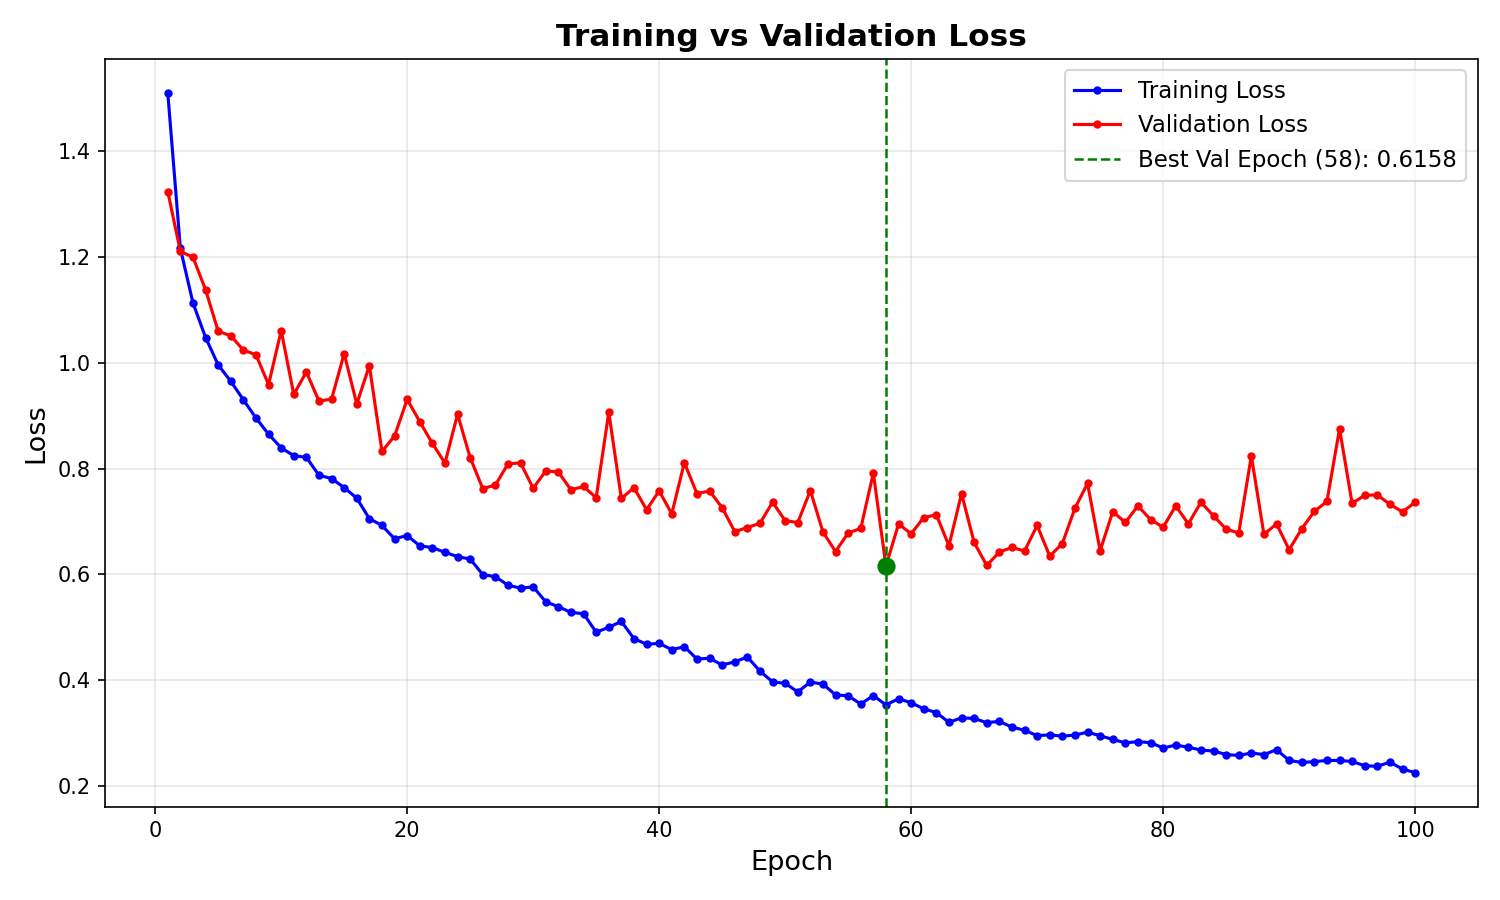

In [4]:
from IPython.display import display, Image as IPImage

display(IPImage("loss_curves.png"))
#display(IPImage("confusion_matrix.png"))
#display(IPImage("per_class_accuracy.png"))

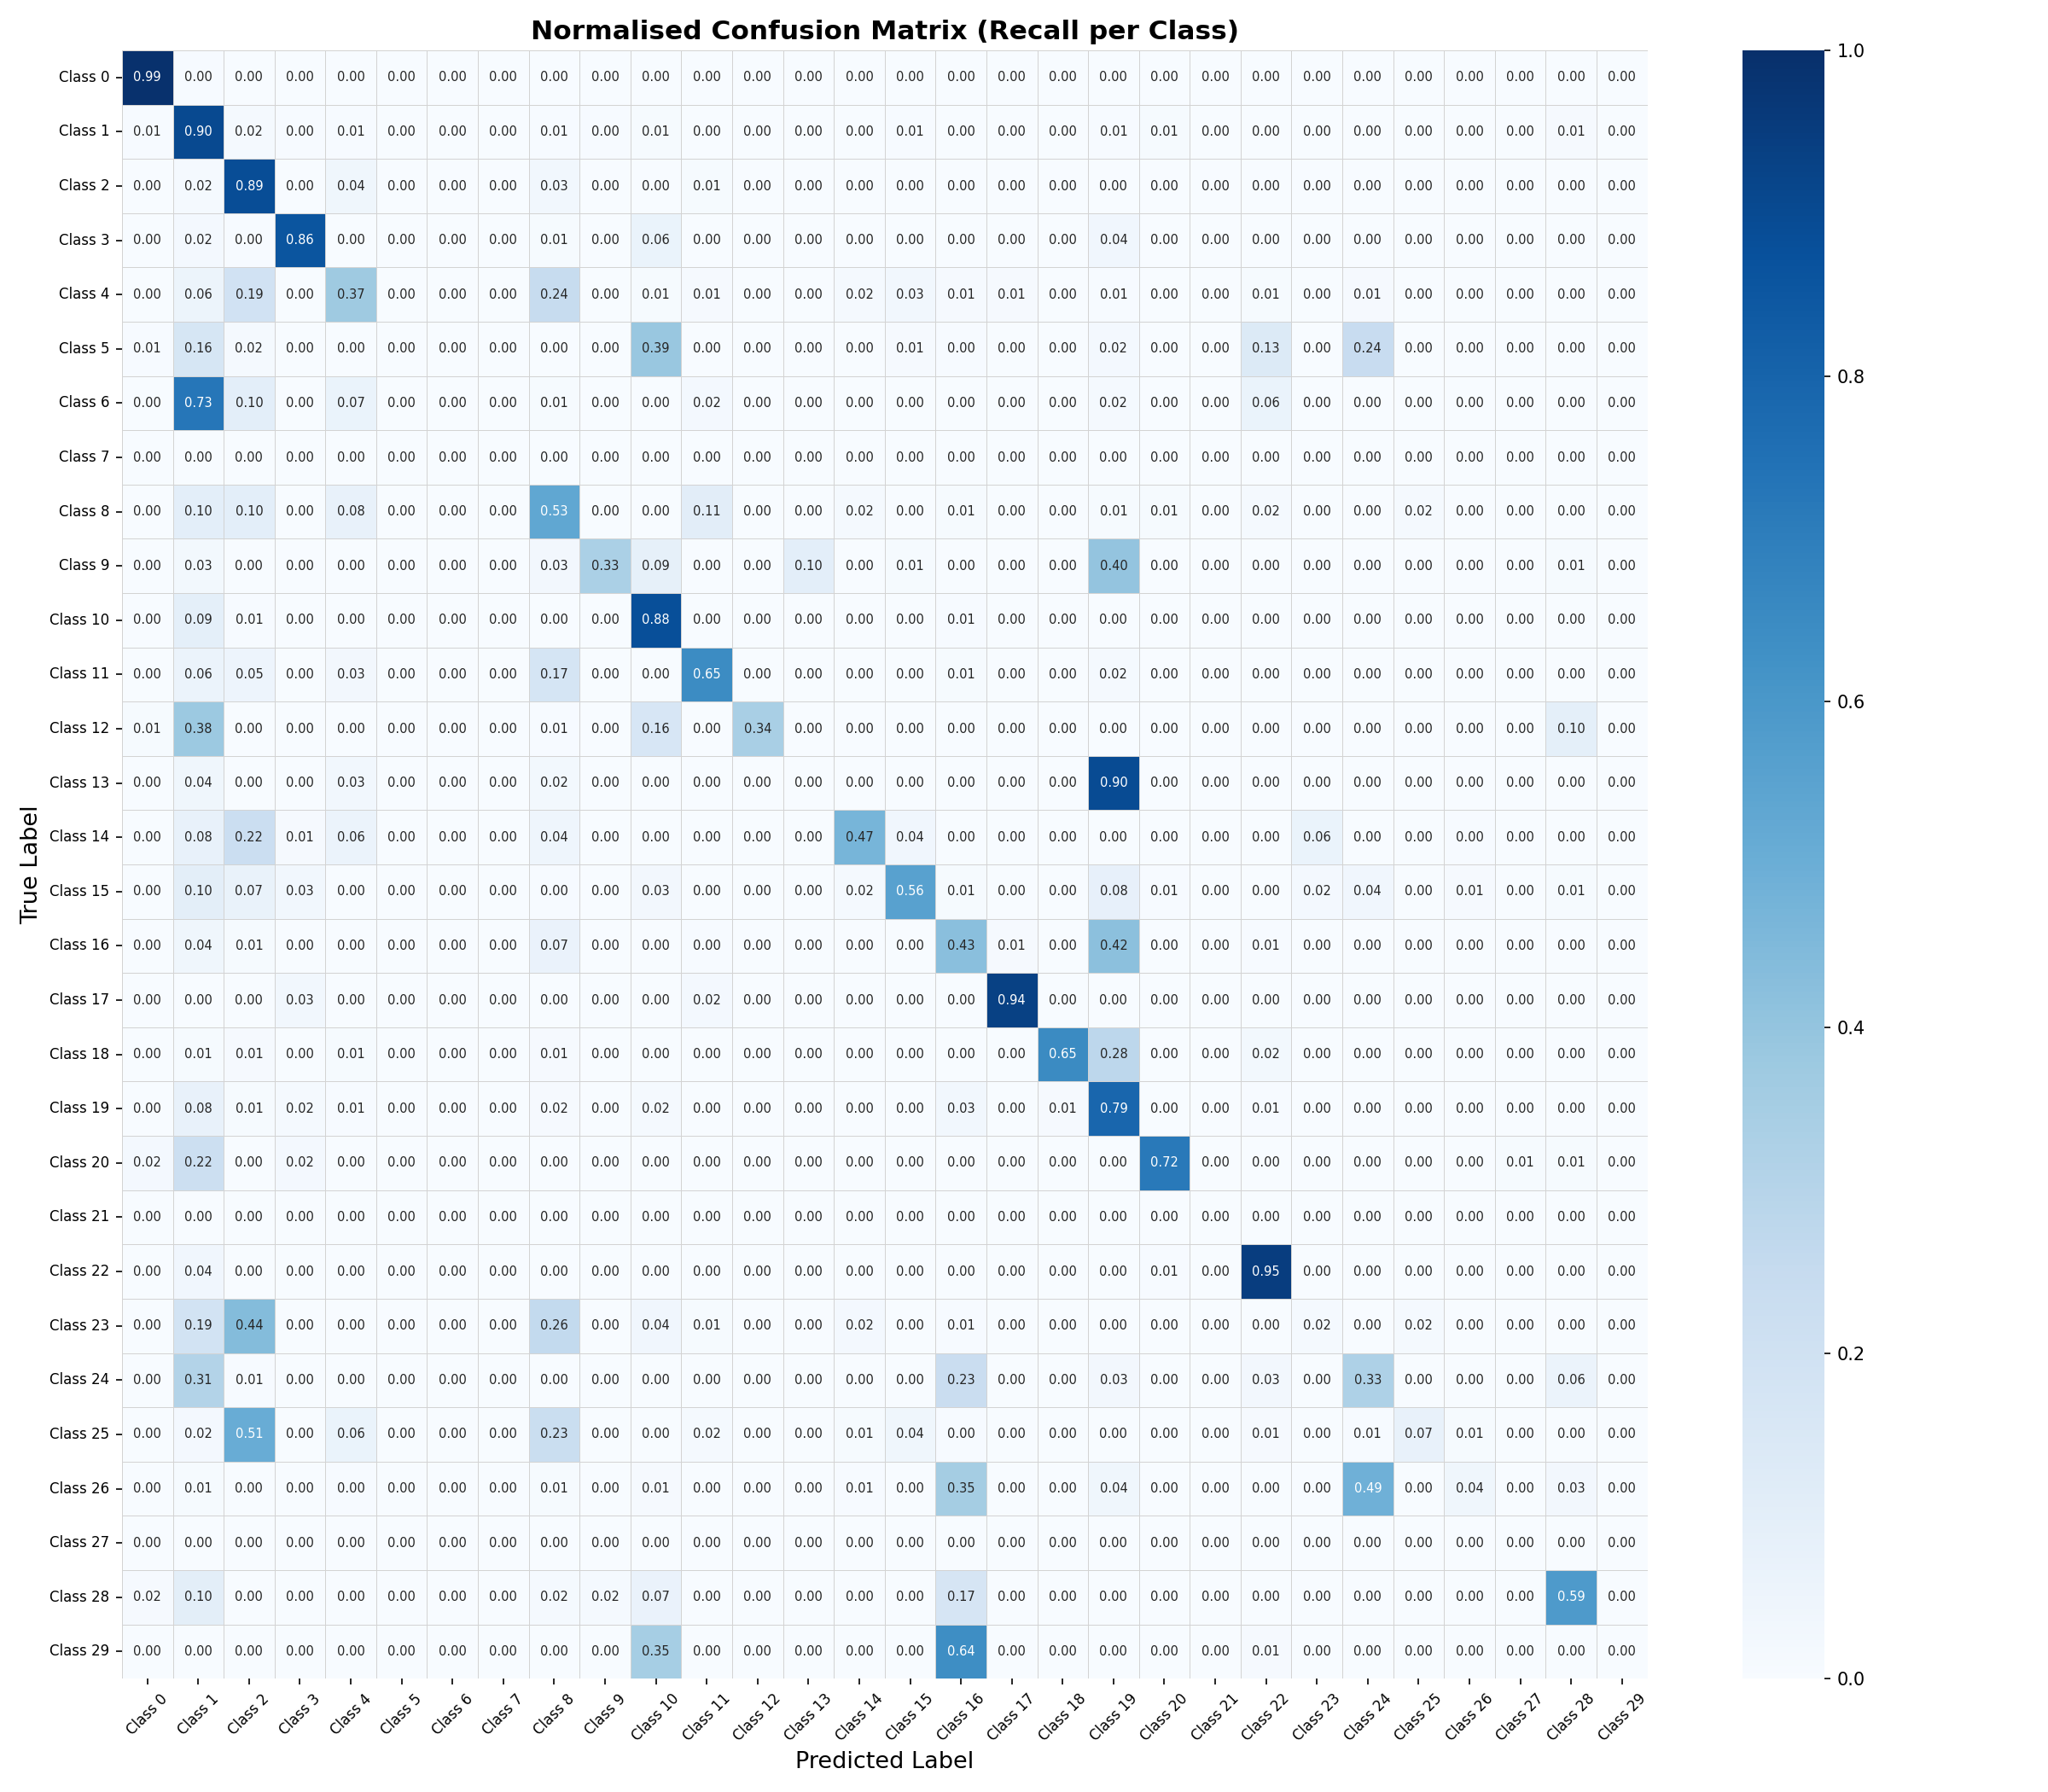

In [8]:
display(IPImage("confusion_matrix.png", width=900))

In [9]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score
import pennylane as qml
from mamba_ssm import Mamba

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ===============================
# DATASET + DATALOADERS
# ===============================

class UAVHSICropDataset(Dataset):
    def __init__(self, root_dir: str, split: str = "Training"):
        if split in ["Training", "Validation"]:
            base = os.path.join(root_dir, split)
        elif split == "Test":
            base = root_dir
        else:
            raise ValueError("split must be Training, Validation or Test")
        self.rs_dir   = os.path.join(base, "rs")
        self.gt_dir   = os.path.join(base, "gt")
        self.rs_files = sorted(glob.glob(os.path.join(self.rs_dir, "*.npy")))
        self.gt_files = sorted(glob.glob(os.path.join(self.gt_dir, "*.npy")))
        assert len(self.rs_files) == len(self.gt_files), "rs/gt count mismatch"

    def __len__(self):
        return len(self.rs_files)

    def normalize_per_band(self, rs):
        mean = rs.mean(axis=(0, 1), keepdims=True)
        std  = rs.std(axis=(0, 1), keepdims=True)
        std[std < 1e-6] = 1e-6
        return (rs - mean) / std

    def __getitem__(self, idx):
        rs = np.load(self.rs_files[idx]).astype(np.float32)
        gt = np.load(self.gt_files[idx]).astype(np.int64)
        rs = self.normalize_per_band(rs)
        rs = torch.from_numpy(rs).permute(2, 0, 1).float()
        gt = torch.from_numpy(gt).long()
        return rs, gt


def make_loaders(root_train, root_test, batch_size=8, num_workers=2):
    train_ds = UAVHSICropDataset(root_train, "Training")
    val_ds   = UAVHSICropDataset(root_train, "Validation")
    test_ds  = UAVHSICropDataset(root_test,  "Test")
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader

# ===============================
# CNN + ATTENTION MODULES
# ===============================

class SpectralSE(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, max(channels // reduction, 8), 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(channels // reduction, 8), channels, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x)


class MultiScaleCNN(nn.Module):
    """use_se flag controls Ablation 4 (no SE block)."""
    def __init__(self, in_channels=200, d_model=64, use_se=True):
        super().__init__()
        self.use_se = use_se
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, d_model, 3, padding=1, bias=False),
            nn.BatchNorm2d(d_model), nn.ReLU(inplace=True)
        )
        self.dec = nn.Sequential(
            nn.Conv2d(32 + d_model, d_model, 3, padding=1, bias=False),
            nn.BatchNorm2d(d_model), nn.ReLU(inplace=True)
        )
        self.se = SpectralSE(d_model) if use_se else nn.Identity()

    def forward(self, x):
        e1   = self.enc1(x)
        e2   = self.enc2(e1)
        e2up = F.interpolate(e2, size=e1.shape[-2:], mode='bilinear', align_corners=False)
        feat = self.dec(torch.cat([e1, e2up], dim=1))
        return self.se(feat)

# ===============================
# QUANTUM HEAD
# ===============================

class QuantumGlobalHead(nn.Module):
    def __init__(self, embed_dim=64, num_classes=30, n_qubits=4, n_layers=2):
        super().__init__()
        self.n_qubits   = n_qubits
        self.reduce_cpu = nn.Linear(embed_dim, n_qubits)
        self.fc_cpu     = nn.Linear(n_qubits, num_classes)

        dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(dev, interface="torch")
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits))
            qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.qlayer = qml.qnn.TorchLayer(circuit, weight_shapes={"weights": (n_layers, n_qubits)})
        self.to(torch.device('cpu'))

    def to(self, *args, **kwargs):
        return super().to(torch.device('cpu'))

    def cuda(self, device=None):
        return self

    def _apply(self, fn):
        super()._apply(fn)
        self.reduce_cpu.to('cpu')
        self.fc_cpu.to('cpu')
        self.qlayer.to('cpu')
        return self

    def forward(self, x_gpu):
        x_cpu = x_gpu.to('cpu').float()
        x_red = torch.tanh(self.reduce_cpu(x_cpu))
        x_q   = self.qlayer(x_red)
        return self.fc_cpu(x_q).to(x_gpu.device)

# ===============================
# LOSS FUNCTIONS
# ===============================

class HybridCELoss_LogCoshDice(nn.Module):
    """Full hybrid loss — baseline."""
    def __init__(self, num_classes=30, alpha=0.5, class_weights=None, eps=1e-5):
        super().__init__()
        self.alpha       = alpha
        self.num_classes = num_classes
        self.eps         = eps
        self.ce_loss     = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None \
                           else nn.CrossEntropyLoss()

    def forward(self, logits, target):
        ce           = self.ce_loss(logits, target)
        pred         = F.softmax(logits, dim=1)
        target_oh    = F.one_hot(target, self.num_classes).permute(0, 3, 1, 2).float()
        intersect    = (pred * target_oh).sum(dim=(0, 2, 3))
        union        = pred.sum(dim=(0, 2, 3)) + target_oh.sum(dim=(0, 2, 3))
        dice         = 1 - (2 * intersect + self.eps) / (union + self.eps)
        log_cosh_dice = torch.log(torch.cosh(dice)).mean()
        return (1 - self.alpha) * ce + self.alpha * log_cosh_dice


class PlainCELoss(nn.Module):
    """Ablation 3a — plain cross-entropy only."""
    def __init__(self, class_weights=None):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None \
                  else nn.CrossEntropyLoss()

    def forward(self, logits, target):
        return self.ce(logits, target)


class FocalLoss(nn.Module):
    """Ablation 3b — CE + Focal Loss."""
    def __init__(self, num_classes=30, gamma=2.0, alpha=0.5, class_weights=None):
        super().__init__()
        self.gamma       = gamma
        self.alpha_w     = alpha
        self.num_classes = num_classes
        self.ce          = nn.CrossEntropyLoss(weight=class_weights, reduction='none') if class_weights is not None \
                           else nn.CrossEntropyLoss(reduction='none')
        self.ce_mean     = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None \
                           else nn.CrossEntropyLoss()

    def forward(self, logits, target):
        ce_loss  = self.ce(logits, target)
        pt       = torch.exp(-ce_loss)
        focal    = ((1 - pt) ** self.gamma * ce_loss).mean()
        plain_ce = self.ce_mean(logits, target)
        return (1 - self.alpha_w) * plain_ce + self.alpha_w * focal

# ===============================
# MAIN MODEL  (configurable)
# ===============================

class CNN_BiSpectralMamba_Quantum(nn.Module):
    """
    Flags:
      use_quantum   – Ablation 1 (no quantum head when False)
      use_bimamba   – Ablation 2 (unidirectional Mamba when False)
      use_se        – Ablation 4 (no SE block when False)
    """
    def __init__(self, in_channels=200, num_classes=30, d_model=64, d_state=16,
                 alpha_init=0.0, use_quantum=True, use_bimamba=True, use_se=True):
        super().__init__()
        self.num_classes  = num_classes
        self.use_quantum  = use_quantum
        self.use_bimamba  = use_bimamba

        self.cnn            = MultiScaleCNN(in_channels, d_model, use_se=use_se)
        self.mamba_forward  = Mamba(d_model=d_model, d_state=d_state, d_conv=4, expand=2)
        self.mamba_backward = Mamba(d_model=d_model, d_state=d_state, d_conv=4, expand=2) \
                              if use_bimamba else None
        self.cls_head       = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, num_classes))

        if use_quantum:
            self.quantum_head = QuantumGlobalHead(d_model, num_classes)
            self.alpha        = nn.Parameter(torch.tensor(alpha_init))

    def forward(self, x, output_size):
        B, C, H_in, W_in = x.shape
        feat   = self.cnn(x)
        tokens = feat.permute(0, 2, 3, 1).reshape(B, -1, feat.shape[1])

        fwd = self.mamba_forward(tokens)
        if self.use_bimamba:
            bwd   = torch.flip(self.mamba_backward(torch.flip(tokens, dims=[1])), dims=[1])
            fused = fwd + bwd
        else:
            fused = fwd

        classical     = self.cls_head(fused)
        classical_map = classical.view(B, H_in, W_in, self.num_classes).permute(0, 3, 1, 2).contiguous()

        if self.use_quantum:
            global_token = fused.mean(dim=1)
            logits_q     = self.quantum_head(global_token)
            logits_q     = logits_q.view(B, self.num_classes, 1, 1).expand_as(classical_map)
            logits       = classical_map + torch.tanh(self.alpha) * logits_q
        else:
            logits = classical_map

        return F.interpolate(logits, size=output_size, mode="bilinear", align_corners=False)

# ===============================
# TRAIN + EVAL ONE CONFIG
# ===============================

def run_experiment(name, model, criterion, train_loader, val_loader, test_loader,
                   device, epochs=100, save_dir="ablation_results"):
    os.makedirs(save_dir, exist_ok=True)
    optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    ckpt_path = os.path.join(save_dir, f"best_{name}.pth")

    print(f"\n{'='*60}")
    print(f"  ABLATION: {name}")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        # ── Train ──────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        for rs, gt in tqdm(train_loader, desc=f"[{name}] Epoch {epoch}/{epochs} Train", leave=False):
            rs, gt = rs.to(device), gt.to(device)
            optimizer.zero_grad()
            logits = model(rs, gt.shape[-2:])
            loss   = criterion(logits, gt)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        avg_train = epoch_loss / len(train_loader)
        train_losses.append(avg_train)

        # ── Validate ───────────────────────────────────────────────
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for rs, gt in val_loader:
                rs, gt = rs.to(device), gt.to(device)
                logits = model(rs, gt.shape[-2:])
                val_loss_sum += criterion(logits, gt).item()
                val_correct  += (logits.argmax(1) == gt).sum().item()
                val_total    += gt.numel()
        avg_val = val_loss_sum / len(val_loader)
        val_oa  = val_correct / val_total
        val_losses.append(avg_val)

        print(f"  Epoch {epoch:3d} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Val OA: {val_oa*100:.2f}%")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), ckpt_path)

    # ── Test ───────────────────────────────────────────────────────
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    all_preds, all_gts = [], []
    with torch.no_grad():
        for rs, gt in tqdm(test_loader, desc=f"[{name}] Testing"):
            rs, gt = rs.to(device), gt.to(device)
            logits = model(rs, gt.shape[-2:])
            all_preds.extend(logits.argmax(1).cpu().numpy().ravel())
            all_gts.extend(gt.cpu().numpy().ravel())

    all_preds = np.array(all_preds)
    all_gts   = np.array(all_gts)
    oa    = (all_preds == all_gts).mean() * 100
    kappa = cohen_kappa_score(all_gts, all_preds)

    return train_losses, val_losses, oa, kappa

# ===============================
# COMBINED LOSS PLOT
# ===============================

def plot_combined_losses(results_dict, save_path="ablation_loss_curves.png"):
    """
    2×2 grid — one subplot per ablation, each showing train + val loss.
    results_dict: { name: (train_losses, val_losses, oa, kappa) }
    """
    names  = list(results_dict.keys())
    colors = [('#2196F3', '#F44336'), ('#4CAF50', '#FF9800'),
              ('#9C27B0', '#E91E63'), ('#00BCD4', '#FF5722')]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Ablation Studies — Training vs Validation Loss', fontsize=16, fontweight='bold', y=1.01)
    axes = axes.flatten()

    for idx, name in enumerate(names):
        train_losses, val_losses, oa, kappa = results_dict[name]
        ax     = axes[idx]
        epochs = range(1, len(train_losses) + 1)
        tc, vc = colors[idx]

        ax.plot(epochs, train_losses, color=tc, linewidth=1.8, label='Train Loss')
        ax.plot(epochs, val_losses,   color=vc, linewidth=1.8, linestyle='--', label='Val Loss')

        best_ep  = int(np.argmin(val_losses)) + 1
        best_val = min(val_losses)
        ax.axvline(x=best_ep, color='green', linestyle=':', linewidth=1.2,
                   label=f'Best epoch: {best_ep}')
        ax.scatter([best_ep], [best_val], color='green', zorder=5, s=50)

        ax.set_title(f'{name}\nOA: {oa:.2f}%  |  Kappa: {kappa:.4f}',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Loss',  fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"\nCombined loss plot saved → {save_path}")

# ===============================
# SUMMARY TABLE
# ===============================

def print_summary_table(results_dict):
    print("\n" + "="*65)
    print(f"  {'ABLATION STUDY SUMMARY':^61}")
    print("="*65)
    print(f"  {'Ablation':<35} {'OA (%)':>10} {'Kappa':>10}")
    print("-"*65)
    for name, (_, _, oa, kappa) in results_dict.items():
        print(f"  {name:<35} {oa:>10.2f} {kappa:>10.4f}")
    print("="*65)

# ===============================
# MAIN
# ===============================

def main():
    root_train = "/home/mkhan186/scratch/uavhsi/Train"
    root_test  = "/home/mkhan186/scratch/uavhsi/Test"
    device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    save_dir   = "/home/mkhan186/scratch/uavhsi/ablation_results"
    EPOCHS     = 100

    train_loader, val_loader, test_loader = make_loaders(root_train, root_test, batch_size=8)

    # Shared class weights (computed once, reused for all experiments)
    all_gts_train = np.concatenate([gt.numpy().ravel() for _, gt in train_loader])
    class_counts  = np.bincount(all_gts_train, minlength=30)
    class_weights = torch.tensor(
        1.0 / (np.sqrt(class_counts) + 1e-6) ** 0.7, device=device
    ).float()

    in_channels = next(iter(train_loader))[0].shape[1]

    # ── Define all 4 ablations ──────────────────────────────────────────────
    ablations = [
        {
            "name":      "Ablation 1: No Quantum Head",
            "model_cfg": dict(use_quantum=False, use_bimamba=True, use_se=True),
            "loss":      HybridCELoss_LogCoshDice(num_classes=30, alpha=0.5, class_weights=class_weights),
        },
        {
            "name":      "Ablation 2: Unidirectional Mamba",
            "model_cfg": dict(use_quantum=True, use_bimamba=False, use_se=True),
            "loss":      HybridCELoss_LogCoshDice(num_classes=30, alpha=0.5, class_weights=class_weights),
        },
        {
            "name":      "Ablation 3: Plain CE Loss Only",
            "model_cfg": dict(use_quantum=True, use_bimamba=True, use_se=True),
            "loss":      PlainCELoss(class_weights=class_weights),
        },
        {
            "name":      "Ablation 4: No SE Block",
            "model_cfg": dict(use_quantum=True, use_bimamba=True, use_se=False),
            "loss":      HybridCELoss_LogCoshDice(num_classes=30, alpha=0.5, class_weights=class_weights),
        },
    ]

    results_dict = {}

    for cfg in ablations:
        torch.manual_seed(SEED)
        np.random.seed(SEED)

        model = CNN_BiSpectralMamba_Quantum(
            in_channels=in_channels, num_classes=30,
            **cfg["model_cfg"]
        ).to(device)

        train_losses, val_losses, oa, kappa = run_experiment(
            name         = cfg["name"],
            model        = model,
            criterion    = cfg["loss"],
            train_loader = train_loader,
            val_loader   = val_loader,
            test_loader  = test_loader,
            device       = device,
            epochs       = EPOCHS,
            save_dir     = save_dir,
        )

        results_dict[cfg["name"]] = (train_losses, val_losses, oa, kappa)

        # Print result immediately after each ablation finishes
        print(f"\n  ✔  {cfg['name']}")
        print(f"     TEST OA:    {oa:.2f}%")
        print(f"     TEST KAPPA: {kappa:.4f}")

    # ── Final combined plot ─────────────────────────────────────────────────
    plot_combined_losses(
        results_dict,
        save_path=os.path.join(save_dir, "ablation_loss_curves.png")
    )

    # ── Summary table ───────────────────────────────────────────────────────
    print_summary_table(results_dict)


if __name__ == "__main__":
    main()


  ABLATION: Ablation 1: No Quantum Head


  Epoch   1 | Train Loss: 1.4441 | Val Loss: 1.3233 | Val OA: 53.84%


  Epoch   2 | Train Loss: 1.1699 | Val Loss: 1.1512 | Val OA: 61.02%


  Epoch   3 | Train Loss: 1.0895 | Val Loss: 1.2056 | Val OA: 61.97%


  Epoch   4 | Train Loss: 1.0307 | Val Loss: 1.0407 | Val OA: 66.65%


...

  Epoch  99 | Train Loss: 0.2132 | Val Loss: 0.7518 | Val OA: 81.88%


/tmp/ipykernel_1361660/1687005357.py:316: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=device))


  Epoch 100 | Train Loss: 0.2151 | Val Loss: 0.7215 | Val OA: 78.94%


[Ablation 4: No SE Block] Testing: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 16.99it/s]



  ✔  Ablation 4: No SE Block
     TEST OA:    84.37%
     TEST KAPPA: 0.8156

Combined loss plot saved → /home/mkhan186/scratch/uavhsi/ablation_results/ablation_loss_curves.png

                     ABLATION STUDY SUMMARY                    
  Ablation                                OA (%)      Kappa
-----------------------------------------------------------------
  Ablation 1: No Quantum Head              83.51     0.8065
  Ablation 2: Unidirectional Mamba         79.50     0.7559
  Ablation 3: Plain CE Loss Only           85.24     0.8264
  Ablation 4: No SE Block                  84.37     0.8156
